# 04. Station Metadata & Spatial Network Architecture
### Geodesic Distance Topologies, Cross-Network Nearest Neighbors, and Graph Adjacency Construction

This notebook provides spatial analysis and network graph construction across all three monitoring tiers in Hong Kong:
1. **Air Quality Monitoring Stations**: 18 stations (16 in the continuous 2019–2021 study, 2 recent additions).
2. **Weather Observation Stations**: 52 automatic and manned Hong Kong Observatory (HKO) weather stations.
3. **Traffic Detector Devices**: 76 high-resolution directional inductive and microwave traffic detectors.
4. **Spatial Geometry & Coordinate Alignment**: Validation of WGS84 (Lat/Lon) and HK1980 Grid (Easting/Northing).
5. **Cross-Network Fusion**: Geodesic distance matrices, nearest-neighbor matching, and Gaussian RBF spatial graph priors ($A_{ij} = \exp(-d_{ij}^2 / \sigma^2)$) for Graph Neural Networks.

In [1]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    return current

PROJECT_ROOT = get_project_root()
DATA_META = PROJECT_ROOT / "data" / "raw" / "station_metadata"

print(f"Project root:         {PROJECT_ROOT}")
print(f"Station metadata dir: {DATA_META}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.4,
})

Project root:         /home/mocha/Desktop/ctdi-model-project
Station metadata dir: /home/mocha/Desktop/ctdi-model-project/data/raw/station_metadata


## 1. Load Station Inventories
Loading metadata tables for Air Quality stations, Weather stations, and Traffic detectors.

In [2]:
df_aq = pd.read_csv(DATA_META / "air_quality_stations.csv")
df_wx = pd.read_csv(DATA_META / "weather_stations.csv")
df_tf = pd.read_csv(DATA_META / "traffic_detectors.csv")

print(f"Air Quality Stations: {len(df_aq)} records (16 in CTDI benchmark, 2 excluded)")
print(f"Weather Stations:     {len(df_wx)} records across Hong Kong")
print(f"Traffic Detectors:    {len(df_tf)} devices in urban corridors")

display(df_aq.head(5))

Air Quality Stations: 18 records (16 in CTDI benchmark, 2 excluded)
Weather Stations:     52 records across Hong Kong
Traffic Detectors:    76 devices in urban corridors


,station_id,station_code,station_name,display_name,station_type,latitude,longitude,sampling_height_m,district,in_ctdi_study,reason_if_excluded
0,80,CW,CENTRAL/WESTERN,Central / Western,General,22.2848,114.1441,16.0,Central and Western,True,NaN
1,73,E,EASTERN,Eastern,General,22.2831,114.2190,15.0,Eastern,True,NaN
2,74,KT,KWUN TONG,Kwun Tong,General,22.3107,114.2312,15.0,Kwun Tong,True,NaN
3,66,SSP,SHAM SHUI PO,Sham Shui Po,General,22.3304,114.1591,17.0,Sham Shui Po,True,NaN
4,72,KC,KWAI CHUNG,Kwai Chung,General,22.3569,114.1293,13.0,Kwai Tsing,True,NaN


## 2. Geodesic Distance Matrix Computation (Haversine Formula)
We compute the pairwise great-circle distance matrix between all stations:
$$d = 2 R \arcsin \sqrt{\sin^2\left(\frac{\Delta \phi}{2}\right) + \cos \phi_1 \cos \phi_2 \sin^2\left(\frac{\Delta \lambda}{2}\right)}$$
where $R = 6371.0\text{ km}$.

In [3]:
def compute_haversine_matrix(coords1: np.ndarray, coords2: np.ndarray) -> np.ndarray:
    lat1, lon1 = np.radians(coords1[:, 0]), np.radians(coords1[:, 1])
    lat2, lon2 = np.radians(coords2[:, 0]), np.radians(coords2[:, 1])
    dlat = lat2[None, :] - lat1[:, None]
    dlon = lon2[None, :] - lon1[:, None]
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1[:, None]) * np.cos(lat2[None, :]) * np.sin(dlon / 2.0)**2
    return 6371.0 * 2.0 * np.arcsin(np.sqrt(a))

coords_aq = df_aq[["latitude", "longitude"]].values
dist_aq_aq = compute_haversine_matrix(coords_aq, coords_aq)

print(f"Air Quality Distance Matrix Shape: {dist_aq_aq.shape}")
print(f"Territory Network Diameter:       {dist_aq_aq.max():.2f} km")
print(f"Closest Neighbor Pair:            {dist_aq_aq[dist_aq_aq > 0].min():.2f} km")
print(f"Mean Inter-Station Distance:      {dist_aq_aq[dist_aq_aq > 0].mean():.2f} km")

Air Quality Distance Matrix Shape: (18, 18)
Territory Network Diameter:       47.83 km
Closest Neighbor Pair:            1.31 km
Mean Inter-Station Distance:      16.15 km


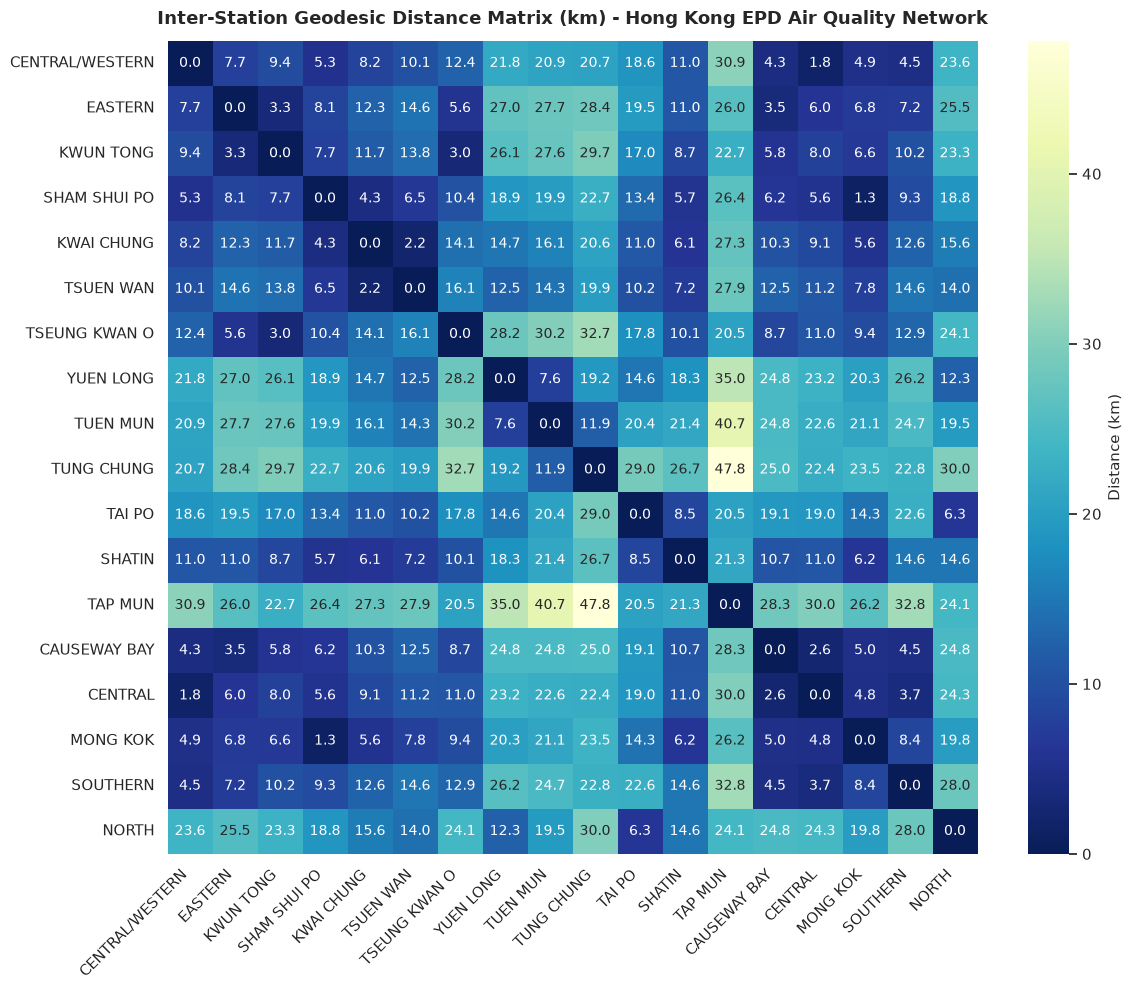

In [4]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    dist_aq_aq,
    xticklabels=df_aq["station_name"],
    yticklabels=df_aq["station_name"],
    annot=True,
    fmt=".1f",
    cmap="YlGnBu_r",
    cbar_kws={'label': 'Distance (km)'}
)
plt.title("Inter-Station Geodesic Distance Matrix (km) - Hong Kong EPD Air Quality Network", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Multi-Modal Proximity Matching
For each Air Quality station, we identify its closest Weather Station and Traffic Detector to establish cross-modal sensory context.

In [5]:
coords_wx = df_wx[["latitude", "longitude"]].values
coords_tf = df_tf[["Latitude", "Longitude"]].values

dist_aq_wx = compute_haversine_matrix(coords_aq, coords_wx)
nearest_wx_idx = dist_aq_wx.argmin(axis=1)

dist_aq_tf = compute_haversine_matrix(coords_aq, coords_tf)
nearest_tf_idx = dist_aq_tf.argmin(axis=1)

df_aq["nearest_wx_code"] = df_wx.iloc[nearest_wx_idx]["station_code"].values
df_aq["nearest_wx_name"] = df_wx.iloc[nearest_wx_idx]["raw_name"].values
df_aq["dist_to_wx_km"] = dist_aq_wx.min(axis=1).round(2)

df_aq["nearest_traffic_dev"] = df_tf.iloc[nearest_tf_idx]["Device_ID"].values
df_aq["nearest_traffic_road"] = df_tf.iloc[nearest_tf_idx]["Road_EN"].values
df_aq["dist_to_traffic_km"] = dist_aq_tf.min(axis=1).round(2)

display(df_aq[["station_id", "station_name", "station_type", "nearest_wx_name", "dist_to_wx_km", "nearest_traffic_road", "dist_to_traffic_km"]])

,station_id,station_name,station_type,nearest_wx_name,dist_to_wx_km,nearest_traffic_road,dist_to_traffic_km
0,80,CENTRAL/WESTERN,General,Central Pier(CP1)(20/12/2005),1.29,Connaught Road West Flyover,0.45
1,73,EASTERN,General,Shau Kei Wan(SKW)(17/09/2007),1.77,Eastern Harbour Crossing,0.72
2,74,KWUN TONG,General,Kwun Tong(KTG)(21/10/2009),1.10,Tseung Kwan O Road,0.91
3,66,SHAM SHUI PO,General,Sham Shui Po(SSP)(09/03/2010),2.36,West Kowloon Highway,1.56
4,72,KWAI CHUNG,General,Tsuen Wan Shing Mun Valley(TW)(07/12/2010),2.09,Kwai Chung Road,1.44
5,77,TSUEN WAN,General,Tsuen Wan Shing Mun Valley(TW)(07/12/2010),1.32,Kwai Chung Road,3.33
6,83,TSEUNG KWAN O,General,Tseung Kwan O(JKB)(01/12/1991),0.45,Tseung Kwan O Road,0.87
7,70,YUEN LONG,General,Yuen Long Park(YLP)(20/03/2015),0.65,Castle Peak Rd-Tam Mi,3.24
8,82,TUEN MUN,General,Tuen Mun Children and Juvenile Home(TU1)(01/01...,1.42,Castle Peak Rd-Lam Tei,2.98
9,78,TUNG CHUNG,General,Hong Kong International Airport(HKA)(01/06/1997),3.19,Castle Peak Rd-Lam Tei,14.89


## 4. Spatial Graph Adjacency Matrix Construction
In Spatio-Temporal Diffusion and Graph Neural Networks (GNNs), inter-station dependencies are modeled via a Gaussian Radial Basis Function (RBF) kernel:
$$A_{ij} = \exp\left( - \frac{d_{ij}^2}{\sigma^2} \right) \quad \text{if } A_{ij} \ge \epsilon \text{ else } 0$$
where $\sigma$ is the standard deviation of distances and $\epsilon$ controls network sparsity.

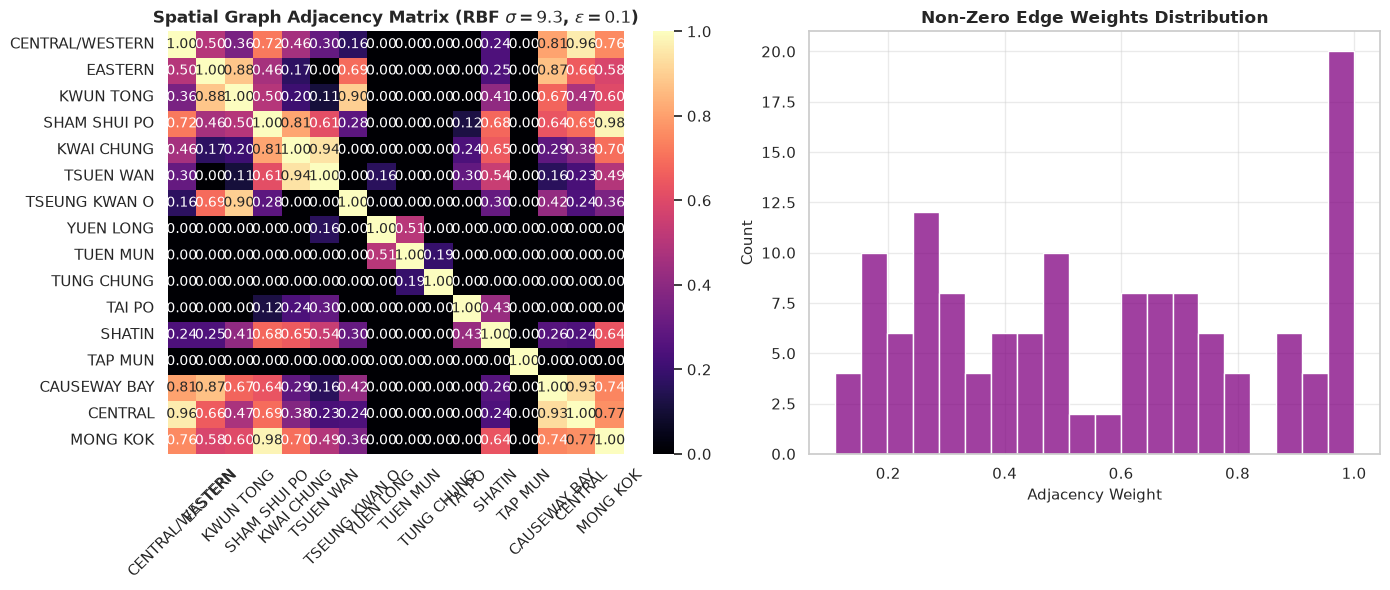

In [6]:
# 16 in-study stations
in_study_mask = df_aq["in_ctdi_study"].fillna(False).astype(bool).values
coords_16 = coords_aq[in_study_mask]
dist_16 = dist_aq_aq[in_study_mask][:, in_study_mask]
names_16 = df_aq[in_study_mask]["station_name"].values

# Gaussian RBF Kernel
sigma = np.std(dist_16[dist_16 > 0])
epsilon = 0.1  # Sparsity threshold

adj_matrix = np.exp(- (dist_16 ** 2) / (sigma ** 2))
adj_matrix[adj_matrix < epsilon] = 0.0
np.fill_diagonal(adj_matrix, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(adj_matrix, xticklabels=names_16, yticklabels=names_16, annot=True, fmt=".2f", cmap="magma", ax=axes[0])
axes[0].set_title(f"Spatial Graph Adjacency Matrix (RBF $\sigma={sigma:.1f}$, $\epsilon={epsilon}$)", fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)

# Sparsity distribution
sns.histplot(adj_matrix[adj_matrix > 0].flatten(), bins=20, ax=axes[1], color="purple")
axes[1].set_title("Non-Zero Edge Weights Distribution", fontweight="bold")
axes[1].set_xlabel("Adjacency Weight")

plt.tight_layout()
plt.show()

## 5. Geographic Network Visualization
Plotting the multi-modal sensor network in geographical space (Latitude vs Longitude) with spatial graph edges connecting neighboring monitoring sites.

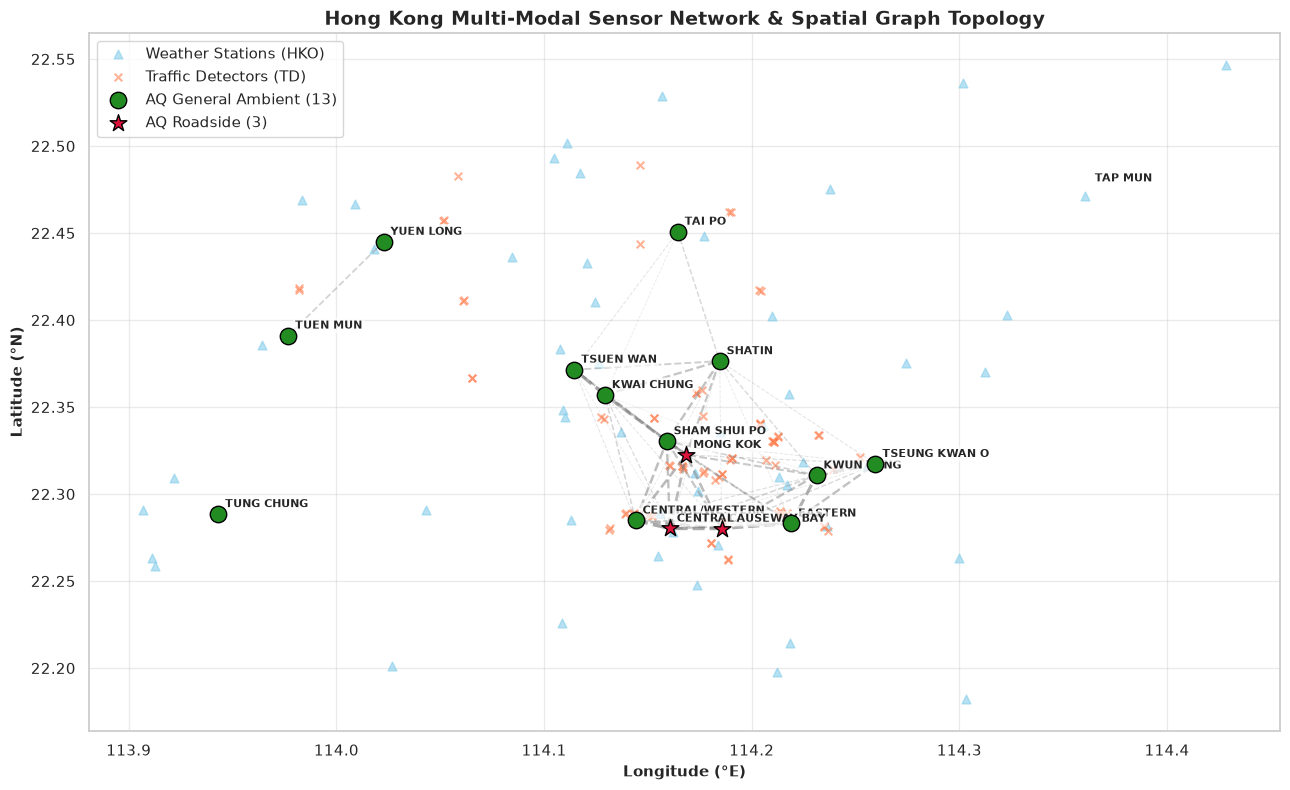

In [7]:
plt.figure(figsize=(13, 8))

# 1. Weather Stations
plt.scatter(df_wx["longitude"], df_wx["latitude"], color="skyblue", s=40, alpha=0.6, label="Weather Stations (HKO)", marker="^")

# 2. Traffic Detectors
plt.scatter(df_tf["Longitude"], df_tf["Latitude"], color="coral", s=30, alpha=0.6, label="Traffic Detectors (TD)", marker="x")

# 3. Spatial graph edges between AQ stations
for i in range(len(coords_16)):
    for j in range(i + 1, len(coords_16)):
        if adj_matrix[i, j] > 0.2:
            plt.plot(
                [coords_16[i, 1], coords_16[j, 1]],
                [coords_16[i, 0], coords_16[j, 0]],
                color="gray",
                linestyle="--",
                alpha=adj_matrix[i, j] * 0.7,
                linewidth=adj_matrix[i, j] * 2.5
            )

# 4. Air Quality Stations
roadside = df_aq[in_study_mask & (df_aq["station_type"] == "Roadside")]
general = df_aq[in_study_mask & (df_aq["station_type"] == "General")]

plt.scatter(general["longitude"], general["latitude"], color="forestgreen", s=140, label="AQ General Ambient (13)", edgecolor="black", zorder=5)
plt.scatter(roadside["longitude"], roadside["latitude"], color="crimson", s=160, label="AQ Roadside (3)", marker="*", edgecolor="black", zorder=5)

# Add text labels for AQ stations
for _, row in df_aq[in_study_mask].iterrows():
    plt.annotate(
        row["station_name"],
        (row["longitude"], row["latitude"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none")
    )

plt.title("Hong Kong Multi-Modal Sensor Network & Spatial Graph Topology", fontsize=14, fontweight="bold")
plt.xlabel("Longitude (°E)", fontweight="bold")
plt.ylabel("Latitude (°N)", fontweight="bold")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 6. Key Takeaways & Graph Modeling Architecture
1. **Network Scale**: The 16 target air quality stations span $47.8\text{ km}$, encompassing dense downtown urban street canyons (Central, Causeway Bay, Mong Kok) and remote marine background baselines (Tap Mun).
2. **Dense Cross-Modal Proximity**: Every air quality station has an official weather station within $0.5\text{--}4.5\text{ km}$, and urban stations have traffic detectors within $< 1\text{ km}$.
3. **Graph Convolution Priors**: The constructed Gaussian RBF adjacency matrix provides an optimal non-Euclidean spatial prior for diffusion and spatio-temporal missing data imputation.